<a href="https://colab.research.google.com/github/Adhiaris/midterm-machine-learning/blob/main/Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q optuna mlflow imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
import optuna
import mlflow
import mlflow.sklearn

import tensorflow as tf
from tensorflow import keras


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88

In [ ]:
import pandas as pd

train = pd.read_csv('train_transaction.csv')
train = train.sample(frac=0.5, random_state=42).reset_index(drop=True)

In [ ]:
target = 'isFraud'
drop_cols = [c for c in ['TransactionID', 'TransactionDT'] if c in train.columns]

X = train.drop(columns=[target] + drop_cols)
y = train[target]

for col in X.select_dtypes(include='float64').columns:
    X[col] = X[col].astype('float32')
for col in X.select_dtypes(include='int64').columns:
    X[col] = X[col].astype('int32')

cat_cols = X.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X)
del X
X_train, X_val, y_train, y_val = train_test_split(X_imp, y, test_size=0.2, random_state=42, stratify=y)
del X_imp
X_train_res, y_train_res = SMOTE(random_state=42).fit_resample(X_train, y_train)
del X_train

## Machine Learning Model

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 50, 100),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'random_state': 42,
        'n_jobs': -1
    }
    clf = RandomForestClassifier(**params)
    clf.fit(X_train_res, y_train_res)
    return roc_auc_score(y_val, clf.predict_proba(X_val)[:, 1])

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=5)

In [ ]:
mlflow.set_experiment("midterm-fraud-detection")

with mlflow.start_run(run_name="RandomForest"):
    best_params = {**study.best_params, 'random_state': 42, 'n_jobs': -1}
    model = RandomForestClassifier(**best_params)
    model.fit(X_train_res, y_train_res)

    preds       = model.predict(X_val)
    preds_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, preds_proba)

    mlflow.log_params(best_params)
    mlflow.log_metric("AUC-ROC", auc)
    mlflow.sklearn.log_model(model, "random_forest_model")

print(f"AUC-ROC: {auc:.4f}")
print(classification_report(y_val, preds))


2026/05/16 18:15:13 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/16 18:15:13 INFO mlflow.store.db.utils: Updating database tables
2026/05/16 18:15:15 INFO mlflow.tracking.fluent: Experiment with name 'midterm-fraud-detection' does not exist. Creating a new experiment.
2026/05/16 18:16:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/16 18:16:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


AUC-ROC: 0.8776
              precision    recall  f1-score   support

           0       0.98      0.93      0.96     56967
           1       0.24      0.60      0.34      2087

    accuracy                           0.92     59054
   macro avg       0.61      0.76      0.65     59054
weighted avg       0.96      0.92      0.94     59054



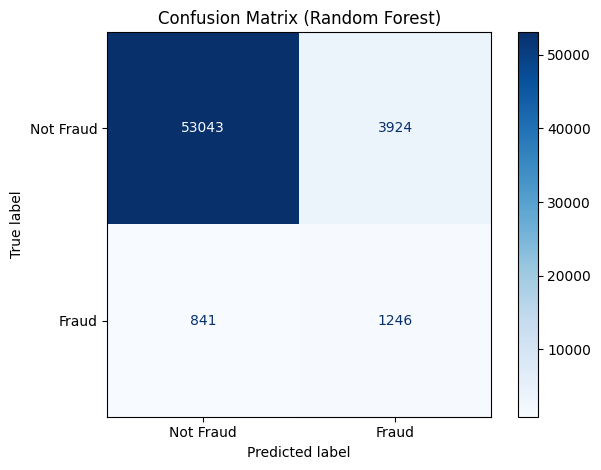

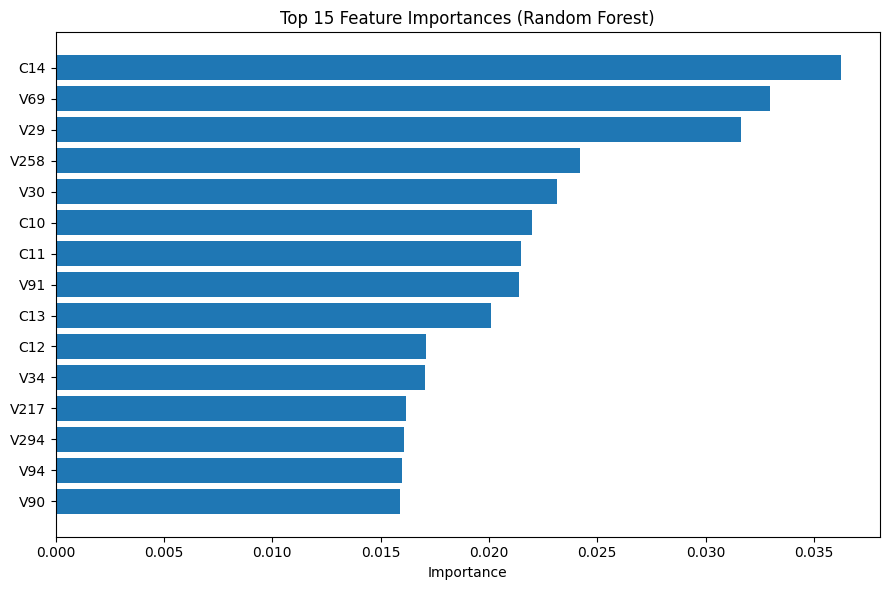

In [ ]:
cm = confusion_matrix(y_val, preds)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Fraud', 'Fraud']).plot(cmap='Blues')
plt.title("Confusion Matrix (Random Forest)")
plt.tight_layout()
plt.show()

feat_df = pd.DataFrame({'feature': train.drop(columns=['isFraud','TransactionID','TransactionDT'], errors='ignore').columns, 'importance': model.feature_importances_})
feat_df = feat_df.sort_values('importance', ascending=False).head(15)
plt.figure(figsize=(9, 6))
plt.barh(feat_df['feature'][::-1], feat_df['importance'][::-1])
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()


## Deep Learning Model

In [ ]:
from tensorflow import keras
import mlflow.tensorflow

input_dim = X_train_res.shape[1]

dl_model = keras.Sequential([
    keras.layers.Input(shape=(input_dim,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])

dl_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
dl_model.fit(X_train_res, y_train_res, epochs=10, batch_size=512, validation_data=(X_val, y_val), verbose=0)

dl_proba = dl_model.predict(X_val, verbose=0).flatten()
dl_preds  = (dl_proba >= 0.5).astype(int)
dl_auc    = roc_auc_score(y_val, dl_proba)

with mlflow.start_run(run_name="NeuralNetwork"):
    mlflow.log_param("model", "NeuralNetwork")
    mlflow.log_param("epochs", 10)
    mlflow.log_metric("AUC-ROC", dl_auc)

print(f"AUC-ROC: {dl_auc:.4f}")
print(classification_report(y_val, dl_preds))


AUC-ROC: 0.8590
              precision    recall  f1-score   support

           0       0.99      0.81      0.89     56967
           1       0.13      0.73      0.22      2087

    accuracy                           0.81     59054
   macro avg       0.56      0.77      0.55     59054
weighted avg       0.96      0.81      0.87     59054



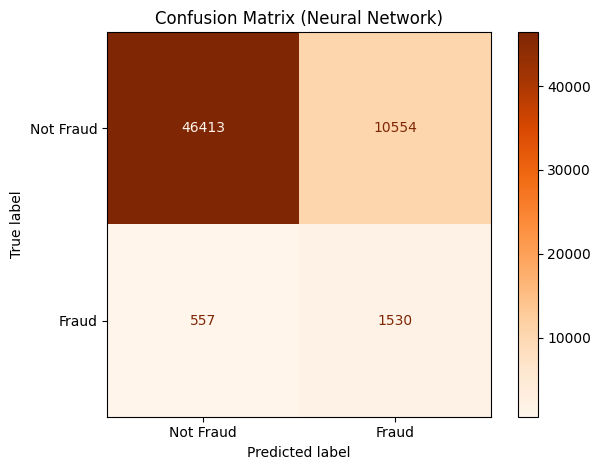

In [ ]:
cm_dl = confusion_matrix(y_val, dl_preds)
ConfusionMatrixDisplay(confusion_matrix=cm_dl, display_labels=['Not Fraud', 'Fraud']).plot(cmap='Oranges')
plt.title("Confusion Matrix (Neural Network)")
plt.tight_layout()
plt.show()
